In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (OneHotEncoder,StandardScaler)
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (RandomForestRegressor,GradientBoostingRegressor)

In [2]:
df = pd.read_csv('/Users/yashpatel/Summer 2026/Data Science Projects/EduVision AI - Student Performance Prediction & Recommendation System/EduVision-AI/Project-Dataset/student-mat.csv',sep=';')
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [3]:
features = [
    "G1",
    "G2",
    "studytime",
    "failures",
    "schoolsup",
    "famsup",
    "internet",
    "higher",
    "goout",
    "freetime",
    "health",
    "absences"
]
features

['G1',
 'G2',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'internet',
 'higher',
 'goout',
 'freetime',
 'health',
 'absences']

In [4]:
target = "G3"
target

'G3'

In [5]:
X = df[features]

y = df[target]
X

,G1,G2,studytime,failures,schoolsup,famsup,internet,higher,goout,freetime,health,absences
0,5,6,2,0,yes,no,no,yes,4,3,3,6
1,5,5,2,0,no,yes,yes,yes,3,3,3,4
2,7,8,2,3,yes,no,yes,yes,2,3,3,10
3,15,14,3,0,no,yes,yes,yes,2,2,5,2
4,6,10,2,0,no,yes,no,yes,2,3,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...
390,9,9,2,2,no,yes,no,yes,4,5,4,11
391,14,16,1,0,no,no,yes,yes,5,4,2,3
392,10,8,1,3,no,no,no,yes,3,5,3,3
393,11,12,1,0,no,no,yes,yes,1,4,5,0


In [6]:
y

0       6
1       6
2      10
3      15
4      10
       ..
390     9
391    16
392     7
393    10
394     9
Name: G3, Length: 395, dtype: int64

In [7]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

In [8]:
numerical_cols

Index(['G1', 'G2', 'studytime', 'failures', 'goout', 'freetime', 'health',
       'absences'],
      dtype='object')

In [9]:
categorical_cols

Index(['schoolsup', 'famsup', 'internet', 'higher'], dtype='object')

In [10]:
preprocessor = ColumnTransformer(transformers=[("num",StandardScaler(),numerical_cols),
                                               ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols)
                                              ])
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
lr_pipeline = Pipeline([("preprocessor", preprocessor),("model", LinearRegression())])

In [13]:
lr_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
lr_pred = lr_pipeline.predict(X_test)
lr_pred

array([ 6.30202459, 12.06926825,  3.19503782,  8.12645572,  8.34905378,
       12.67086247, 19.0067512 ,  6.95563464,  6.80908727, 12.70749881,
       14.83612671,  5.92134059, 13.7189161 , 11.17352797, 14.41609371,
        8.43727951,  6.13578601, 10.83592886, 14.87573693,  8.44240882,
       14.3225716 , 16.16853821, 14.63669101,  5.65584122,  8.11922118,
       19.75510512,  9.9878334 ,  8.4484231 , 17.26465872, 10.24336433,
        9.42424984,  6.64403158, 14.79189432, 12.91463298,  5.79538394,
        3.99890388, -2.30723013, 15.28260989, 11.81414417,  7.37268271,
        5.35993029,  9.94193044, 14.08435735,  7.64953792, 15.45911968,
        9.31547917, 12.24648986, 14.73390887, 12.44177073, 15.61036082,
       13.98448129, 14.58627298, 10.12662408,  7.84483872,  4.26005367,
       13.17592364,  9.59425907,  5.94294274, 14.87268345, 16.275409  ,
       12.70462292,  8.36527865,  6.88068432,  3.85089909,  4.96710091,
       17.53223282,  7.89850918,  9.15665823,  9.70485965, 15.54

In [15]:
lr_mae = mean_absolute_error(y_test,lr_pred)
lr_r2 = r2_score(y_test,lr_pred)

print("MAE:",lr_mae)
print("R2:",lr_r2)

MAE: 1.4428901582617482
R2: 0.7690482567432624


In [16]:
# Bulding Random Forest Pipeline

rf_pipeline = Pipeline([("preprocessor", preprocessor),("model", RandomForestRegressor(n_estimators=300,random_state=42))])

In [17]:
rf_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
rf_pred = rf_pipeline.predict(X_test)
rf_pred

array([ 8.86      , 11.69333333,  6.73666667,  9.49333333,  9.11      ,
       13.33      , 18.98      ,  7.57666667,  5.25333333, 12.80333333,
       15.53      ,  7.27      , 14.46666667, 11.65      , 14.02666667,
        8.57      ,  2.51333333, 11.13      , 15.47      ,  6.69      ,
       13.84666667, 15.84      , 15.04666667,  6.22      ,  6.6       ,
       18.35333333, 10.06666667,  5.98      , 18.09333333, 10.52333333,
        8.97666667,  8.18      , 15.62333333, 13.21      ,  1.76333333,
        6.04666667,  0.04333333, 14.87      , 11.44333333,  8.17333333,
        6.93333333,  9.94      , 14.10666667,  9.08666667, 14.79      ,
        7.03333333, 12.07666667, 14.13333333, 12.91666667, 15.3       ,
       13.28333333, 15.33333333,  9.73333333,  9.53333333,  5.84333333,
       13.08      , 10.99      ,  1.73333333, 15.61333333, 16.01666667,
       12.99666667,  9.43      ,  8.2       ,  6.04666667,  7.5       ,
       18.07333333,  8.88333333, 10.12      ,  9.94      , 15.60

In [19]:
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_r2 = r2_score(y_test,rf_pred)

print("MAE:", rf_mae)
print("R²:", rf_r2)

MAE: 1.2061181434599155
R²: 0.8131617844354841


In [20]:
# Gradient Boosting Pipeline
gb_pipeline = Pipeline([("preprocessor", preprocessor),("model", GradientBoostingRegressor(random_state=42))])

In [21]:
gb_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
gb_pred = gb_pipeline.predict(X_test)
gb_pred

array([ 9.74669721, 12.38082214,  5.39760298,  9.09736407,  8.90919859,
       12.99839342, 18.1449169 ,  7.89635229,  5.19705703, 12.83433547,
       15.47802523,  7.41702239, 13.8299821 , 11.82586823, 14.25613703,
        9.89266576,  2.1824139 , 10.97288464, 14.38311808,  5.12628296,
       14.10780213, 15.7690157 , 15.16111793,  5.79925908,  8.04401637,
       18.80915161, 10.69482374,  6.34922569, 17.96269348, 11.40305447,
        8.7760936 ,  8.47119138, 15.51837881, 12.97633578,  1.35898437,
        6.43403301, -0.27585312, 15.03508825, 12.05628048,  9.23401815,
        5.99963317, 10.9784287 , 14.51073805,  8.50304304, 15.29130367,
        8.90420086, 11.7616809 , 14.01270842, 13.01675829, 15.24923583,
       13.54715023, 15.58705348,  9.83945485,  9.00520635,  6.51933962,
       13.05604974, 10.58798809,  1.56591269, 15.273165  , 15.77549745,
       12.98367673, 10.01957235,  8.07472449,  6.39849886,  6.42582321,
       17.58111993,  9.07294216, 10.28853387,  9.71374396, 15.13

In [23]:
gb_mae = mean_absolute_error(y_test,gb_pred)
gb_r2 = r2_score(y_test,gb_pred)

print("MAE:", gb_mae)
print("R²:", gb_r2)

MAE: 1.1804240857584918
R²: 0.8138186462285149


In [24]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae
    ],
    "R2": [
        lr_r2,
        rf_r2,
        gb_r2
    ]
})

results

,Model,MAE,R2
0,Linear Regression,1.442890,0.769048
1,Random Forest,1.206118,0.813162
2,Gradient Boosting,1.180424,0.813819


In [25]:
rf_model = rf_pipeline.named_steps["model"]

feature_names = (rf_pipeline.named_steps["preprocessor"].get_feature_names_out())
importance_df = pd.DataFrame({"Feature": feature_names,"Importance": rf_model.feature_importances_})
importance_df = importance_df.sort_values(by="Importance",ascending=False)
importance_df.head(15)

,Feature,Importance
1,num__G2,0.789227
7,num__absences,0.119164
6,num__health,0.018128
0,num__G1,0.016444
4,num__goout,0.012191
5,num__freetime,0.009802
2,num__studytime,0.008767
9,cat__schoolsup_yes,0.006997
3,num__failures,0.006437
8,cat__schoolsup_no,0.005423


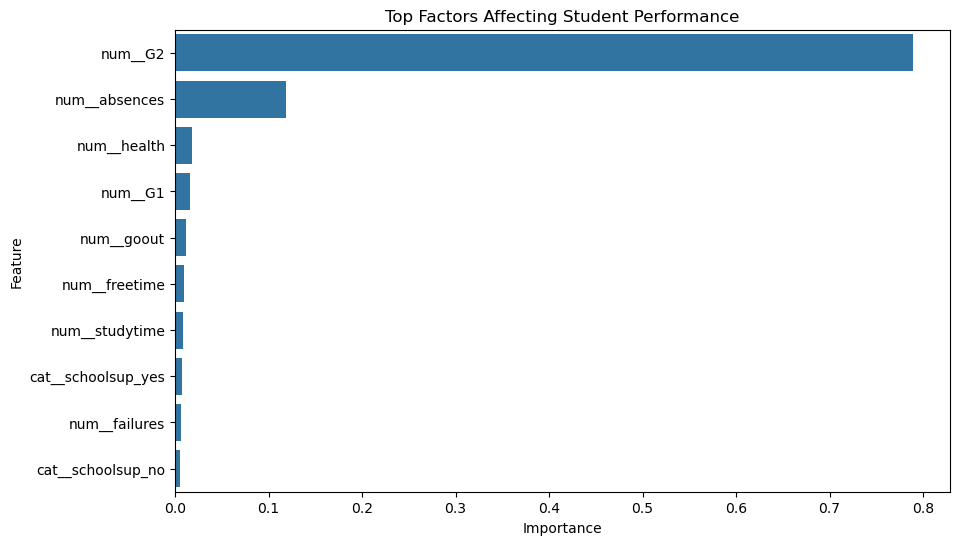

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10),x="Importance",y="Feature")
plt.title("Top Factors Affecting Student Performance")
plt.show()

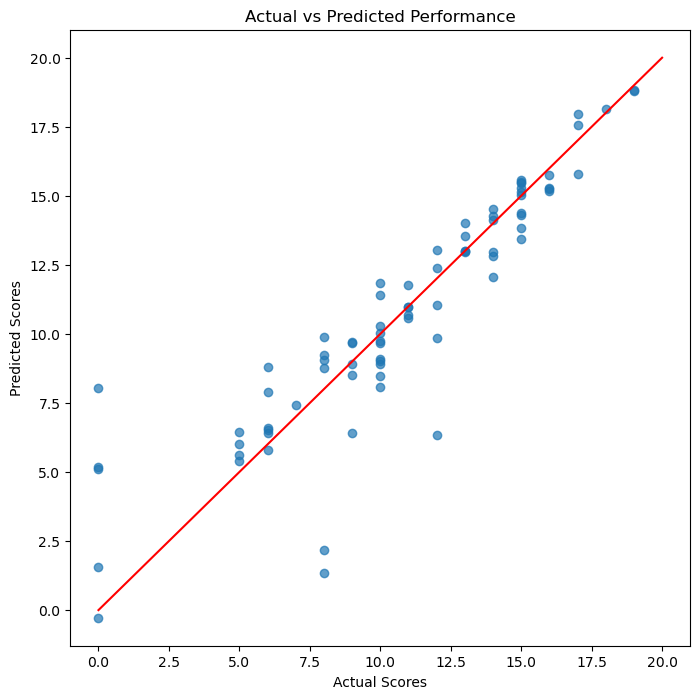

In [30]:
best_pred = gb_pipeline.predict(X_test)
plt.figure(figsize=(8,8))
plt.scatter(y_test,best_pred,alpha=0.7)
plt.plot([0,20],[0,20],color="red")
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Performance")
plt.show()

In [32]:
# Risk Categories

def risk_level(score):
    if score < 8:
        return "High Risk"
    elif score < 12:
        return "Moderate"
    elif score < 16:
        return "Good"
    else:
        return "Excellent"

In [33]:
print(risk_level(6))
print(risk_level(14))
print(risk_level(18))

High Risk
Good
Excellent


In [34]:
def recommendation(
    studytime,
    absences,
    failures
):

    rec = []

    if studytime <= 1:
        rec.append(
            "Increase study time."
        )

    if absences > 10:
        rec.append(
            "Improve attendance."
        )

    if failures > 0:
        rec.append(
            "Focus on weak subjects."
        )

    return rec

In [35]:
import joblib

joblib.dump(
    gb_pipeline,
    "eduvision_model.pkl"
)

['eduvision_model.pkl']

In [36]:
joblib.dump(
    features,
    "feature_columns.pkl"
)

['feature_columns.pkl']

#### print(features)